# 02 — Data Understanding

Goal: understand the raw shape, structure, and quality issues in the SECOM dataset *before*
deciding on any cleaning rules. No values are dropped or imputed in this notebook.


In [1]:

import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import preprocessing as prep
import visualization as viz

df = prep.load_raw_data("../data/raw/uci-secom.csv")
print("Shape:", df.shape)
print("Columns[:5]:", df.columns[:5].tolist())
print("Time range:", df['Time'].min(), "to", df['Time'].max())


Shape: (1567, 592)
Columns[:5]: ['Time', '0', '1', '2', '3']
Time range: 2008-01-08 02:02:00 to 2008-12-10 18:47:00


## Label distribution

The target is `Pass/Fail`, coded -1 = pass, 1 = fail.

Pass units: 1463
Fail units: 104
Fail rate: 6.64%


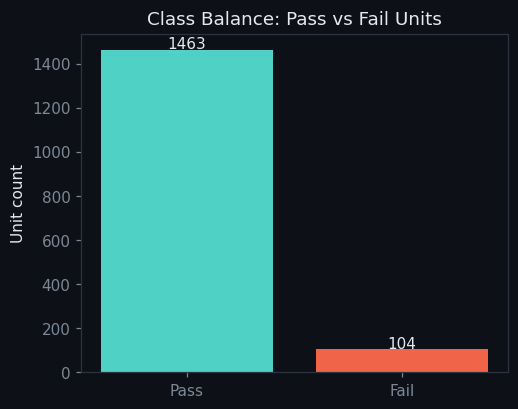

In [2]:

counts = df['Pass/Fail'].value_counts()
pass_n, fail_n = int(counts[-1]), int(counts[1])
fail_rate = 100 * fail_n / len(df)
print(f"Pass units: {pass_n}")
print(f"Fail units: {fail_n}")
print(f"Fail rate: {fail_rate:.2f}%")

fig, ax = plt.subplots(figsize=(5,4))
viz.plot_class_balance(pass_n, fail_n, ax=ax)
plt.show()


**Observation:** the dataset is heavily imbalanced — only 6.6% of units failed. This has
direct consequences for later modeling: accuracy is a misleading metric here (a model that
always predicts "pass" would already score ~93%), so ROC-AUC / average precision / recall on
the fail class will be used instead (see notebook 06).

## Missing data

Sensor columns come from real fab equipment and some readings are missing entirely for a run.

In [3]:

sensor_cols = prep.get_sensor_columns(df)
print("Total sensor columns:", len(sensor_cols))

missing_report = prep.missing_value_report(df, sensor_cols)
print(missing_report.head(10))
print("...")
print(f"Sensors with >0% missing: {(missing_report['missing_pct']>0).sum()}")
print(f"Sensors with >40% missing: {(missing_report['missing_pct']>40).sum()}")


Total sensor columns: 590
     missing_pct
157    91.193363
292    91.193363
293    91.193363
158    91.193363
492    85.577537
358    85.577537
220    85.577537
85     85.577537
517    64.964901
518    64.964901
...
Sensors with >0% missing: 538
Sensors with >40% missing: 32


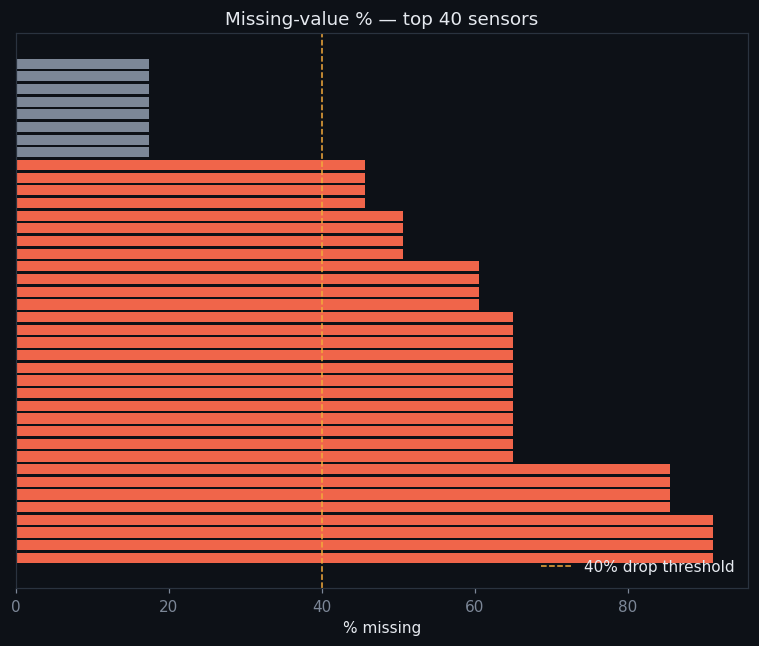

In [4]:

fig, ax = plt.subplots(figsize=(7,6))
viz.plot_missingness(missing_report['missing_pct'], threshold=40, top_n=40, ax=ax)
plt.tight_layout()
plt.show()


**Observation:** there's a clean gap in the missingness distribution — a small group of sensors
(32 of them) are missing on more than 40% of units, while every other sensor is missing on 17%
of units or less. This natural gap is what we'll use to justify the drop threshold in
notebook 03, rather than picking an arbitrary cutoff.

## Zero/near-zero variance sensors

Some sensors may record (almost) the same value on every unit — these carry no information for distinguishing pass/fail.

In [5]:

variances = df[sensor_cols].var(skipna=True)
zero_var_count = int((variances == 0).sum())
print(f"Sensors with exactly zero variance: {zero_var_count} out of {len(sensor_cols)}")
print(f"Sensors with variance < 1e-6: {int((variances < 1e-6).sum())}")


Sensors with exactly zero variance: 116 out of 590
Sensors with variance < 1e-6: 127


## Summary of data understanding findings

| Finding | Value |
|---|---|
| Total units | 1,567 |
| Total sensor columns | 590 |
| Fail rate | 6.64% |
| Sensors with >40% missing | 32 |
| Sensors with zero variance | 116 (once the 32 high-missing ones already visible are set aside) |

These three findings directly motivate the cleaning rules implemented in
`03_data_cleaning.ipynb`.